# **Bibliotecas Utilizadas e Importação do Banco de Dados**

In [297]:
from wordcloud import WordCloud
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import load_iris
import plotly.graph_objects as go
import random
from mpl_toolkits import mplot3d
import plotly.express as px

# **Funções de Análise Exploratória**

In [299]:
def analise_inicial(df):
  print("\nInformações Gerais da Tabela")
  print(df.info())

  print("\nTipo das variáveis")
  display(df.dtypes)

  print("\nPrimeiras 10 Linhas")
  display(df.head(10))

  print("\nUltimas 10 Linhas")
  display(df.tail(10))

  print("\nEstatísticas Descritivas")
  display(df.describe())

  print("\nObservação das Colunas")
  print(df.columns)

  print("\nQuantidade de Linhas e Colunas")
  print(df.shape)
  print()

In [300]:
def verificacao_nulo(df):
  print("Verificação de Números Nulos")
  print(df.isnull().sum())

  print("\nVerificação de Duplicatas")
  print(f"{df.duplicated().sum()}\n")

In [301]:
def classificacao_sentimento(valor):
  if valor < -0.6:
    return 'Muito negativo'
  elif valor >= -0.6 and valor < -0.2:
    return 'Negativo'
  elif valor >= -0.2 and valor < 0.2:
    return 'Neutro'
  elif valor >= 0.2 and valor <= 0.6:
    return 'Positivo'
  elif valor > 0.6:
    return 'Muito Positivo'
  else:
    return 'Default'

In [302]:
def exploracao_do_banco(df):
  analise_inicial(df)
  verificacao_nulo(df)

# **Visualização Das Tabelas do Banco de Dados**

In [303]:
df_avaliacoes = pd.read_csv('avaliacoes.csv')
df_vendedores = pd.read_csv('vendedores.csv')
df_produtos = pd.read_csv('produtos.csv')
df_pedidos = pd.read_csv('pedidos.csv')
df_itens_pedidos = pd.read_csv('itens_pedidos.csv')
df_geolocalizacao = pd.read_csv('geolocalizacao.csv')
df_clientes = pd.read_csv('clientes.csv')
df_pagamentos = pd.read_csv('pagamentos.csv')

In [304]:
lista = [df_avaliacoes, df_vendedores, df_produtos, df_pedidos, df_itens_pedidos, df_geolocalizacao, df_clientes, df_pagamentos]

In [305]:
for i in range(len(lista)):
    exploracao_do_banco(lista[i])


Informações Gerais da Tabela
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
None

Tipo das variáveis


review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object


Primeiras 10 Linhas


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47



Ultimas 10 Linhas


...


Ultimas 10 Linhas


,order_id,payment_sequential,payment_type,payment_installments,payment_value
103876,0872d0faafe0cb56e6f2c594cca1522c,1,credit_card,2,127.92
103877,3531718b24dfd5022fb0d101e10e33b9,1,credit_card,1,194.11
103878,2e3d96522c8c378d4135c12a65c977aa,1,credit_card,4,47.62
103879,c45067032fd84f4cf408730ff5205568,1,credit_card,2,198.94
103880,7159096c5aa9be77f7f0c26c01ee9793,1,credit_card,4,280.65
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54
103885,28bbae6599b09d39ca406b747b6632b1,1,boleto,1,191.58



Estatísticas Descritivas


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000



Observação das Colunas
Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

Quantidade de Linhas e Colunas
(103886, 5)

Verificação de Números Nulos
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Verificação de Duplicatas
0



In [306]:
def dicionario_dados(df):
    return pd.DataFrame({
        'Coluna': df.columns,
        'Tipo': df.dtypes.values,
        'Valores Nulos': df.isnull().sum().values,
        'Duplicados': df.duplicated().sum()
    })

dicionario_dados(df_avaliacoes)

,Coluna,Tipo,Valores Nulos,Duplicados
0,review_id,object,0,0
1,order_id,object,0,0
2,review_score,int64,0,0
3,review_comment_title,object,87656,0
4,review_comment_message,object,58247,0
5,review_creation_date,object,0,0
6,review_answer_timestamp,object,0,0


In [307]:
pedidos = df_pedidos.copy()
avaliacoes = df_avaliacoes.copy()
clientes = df_clientes.copy()
pagamentos = df_pagamentos.copy()
itens = df_itens_pedidos.copy()
produtos = df_produtos.copy()
vendedores = df_vendedores.copy()

In [308]:
df_completo = (
    pedidos

    .merge(
        avaliacoes,
        on='order_id',
        how='left'
    )

    .merge(
        clientes,
        on='customer_id',
        how='left'
    )

    .merge(
        pagamentos,
        on='order_id',
        how='left'
    )

    .merge(
        itens,
        on='order_id',
        how='left'
    )

    .merge(
        produtos,
        on='product_id',
        how='left'
    )

    .merge(
        vendedores,
        on='seller_id',
        how='left',
        suffixes=('', '_seller')
    )

)

In [309]:
# Linhas e Colunas
print(df_completo.shape)

(119143, 39)


In [310]:
# Verificando duplicatas
df_completo.duplicated().sum()

np.int64(0)

In [311]:
# Verificando os valores nulos
df_completo.isnull().sum().sort_values(ascending=False)

review_comment_title             105154
review_comment_message            68898
order_delivered_customer_date      3421
product_name_lenght                2542
product_description_lenght         2542
product_category_name              2542
product_photos_qty                 2542
order_delivered_carrier_date       2086
review_answer_timestamp             997
review_score                        997
review_id                           997
review_creation_date                997
product_width_cm                    853
product_length_cm                   853
product_height_cm                   853
product_weight_g                    853
product_id                          833
shipping_limit_date                 833
price                               833
seller_city                         833
seller_id                           833
order_item_id                       833
freight_value                       833
seller_state                        833
seller_zip_code_prefix              833


In [312]:
df_completo.select_dtypes(include='object').columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'review_id', 'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'customer_unique_id',
       'customer_city', 'customer_state', 'payment_type', 'product_id',
       'seller_id', 'shipping_limit_date', 'product_category_name',
       'seller_city', 'seller_state'],
      dtype='object')

In [313]:
categoricas = ['order_status', 'review_score', 'customer_state', 'product_category_name', 'payment_type', 'customer_city']

In [314]:
for i in range(len(categoricas)):
    df_completo[categoricas[i]] = (
        df_completo[categoricas[i]]
        .astype('category')
    )

In [315]:
df_completo.select_dtypes(include=['int64']).columns

Index(['customer_zip_code_prefix'], dtype='object')

In [316]:
[col for col in df_completo.columns if 'date' in col or 'timestamp' in col]

['order_purchase_timestamp',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'review_creation_date',
 'review_answer_timestamp',
 'shipping_limit_date']

In [317]:
datas = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp',
    'order_delivered_carrier_date',
    'shipping_limit_date'
]

for coluna in datas:
    if coluna in df_completo.columns:
        df_completo[coluna] = pd.to_datetime(
            df_completo[coluna],
            errors='coerce'
        )

In [318]:
df_completo.select_dtypes(include=['float64']).columns

Index(['payment_sequential', 'payment_installments', 'payment_value',
       'order_item_id', 'price', 'freight_value', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix'],
      dtype='object')

In [319]:
df_completo.select_dtypes(include=['datetime64[ns]']).columns

Index(['order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'review_creation_date',
       'review_answer_timestamp', 'shipping_limit_date'],
      dtype='object')

In [320]:
# Padronizar comentários
df_completo['review_comment_message'] = (
    df_completo['review_comment_message']
    .fillna('Sem comentário')
    .str.lower()
    .str.strip()
)

In [321]:
# Padronizar as cidades
df_completo['customer_city'] = (
    df_completo['customer_city']
    .str.lower()
    .str.strip()
)

In [322]:
ids = [
    'order_id',
    'customer_id',
    'seller_id',
    'product_id',
    'review_id'
]

for col in ids:
    if col in df_completo.columns:
        df_completo[col] = df_completo[col].astype('string')

In [323]:
floats = [
    'price',
    'freight_value',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'payment_value'
]

for col in floats:
    if col in df_completo.columns:
        df_completo[col] = df_completo[col].astype('float32')

In [324]:
df_completo.select_dtypes(include=['object']).columns

Index(['review_comment_title', 'review_comment_message', 'customer_unique_id',
       'customer_city', 'seller_city', 'seller_state'],
      dtype='object')

In [325]:
caracteres = ['review_comment_title', 'review_comment_message', 'customer_unique_id', 'seller_city', 'seller_state']
for i in range(len(caracteres)):
    df_completo[caracteres[i]] = (
        df_completo[caracteres[i]]
        .astype('string')
    )

In [326]:
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  string        
 1   customer_id                    119143 non-null  string        
 2   order_status                   119143 non-null  category      
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   review_id                      118146 non-null  string        
 9   review_score                   118146 non-null  category      
 10  review_comment_title           13989 non-null   string        
 11  

In [327]:
df_completo = df_completo[
    (df_completo['review_comment_message'].notna()) &
    (df_completo['review_comment_message'].str.strip() != '') &
    (df_completo['review_comment_message'] != 'sem comentário')
]

# **Análise Sentimental**

##  **Biblioteca Vader**

In [328]:
%pip install vaderSentiment

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [334]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()
df_completo['review_comment_message'] = (
    df_completo['review_comment_message'].fillna('')
)

def calcular_sentimento(texto):
  if texto.strip() == '':
    return 0.0
  return sid.polarity_scores(texto)['compound']

df_completo['pontuacao_vader'] = (
  df_completo['review_comment_message'].apply(calcular_sentimento)
)

In [335]:
df_completo.loc[:, ['review_comment_message', 'pontuacao_vader', 'review_score']]

,review_comment_message,pontuacao_vader,review_score
0,"não testei o produto ainda, mas ele veio corre...",0.000,4.0
1,"não testei o produto ainda, mas ele veio corre...",0.000,4.0
2,"não testei o produto ainda, mas ele veio corre...",0.000,4.0
3,muito bom o produto.,0.000,4.0
5,o produto foi exatamente o que eu esperava e e...,-0.296,5.0
...,...,...,...
119129,"ele não é um mini cajon, é um shaker, ou seja,...",0.000,1.0
119138,so uma peça que veio rachado mas tudo bem rs,0.000,4.0
119139,foi entregue antes do prazo.,0.000,5.0
119140,foi entregue somente 1. quero saber do outro p...,0.000,2.0


## **Biblioteca LeIA**

In [331]:
%pip install leia-br

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [336]:
from LeIA import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()

df_completo['review_comment_message'] = (
    df_completo['review_comment_message'].fillna('')
)

def calcular_sentimentos(texto):
  if texto.strip() == '':
    return 0.0
  return sid.polarity_scores(texto)['compound']

df_completo['pontuacao_leia'] = (
    df_completo['review_comment_message'].apply(calcular_sentimentos)
 )


In [337]:
df_completo.loc[:, ['review_score', 'review_comment_message', 'pontuacao_vader', 'pontuacao_leia']]

,review_score,review_comment_message,pontuacao_vader,pontuacao_leia
0,4.0,"não testei o produto ainda, mas ele veio corre...",0.000,0.5023
1,4.0,"não testei o produto ainda, mas ele veio corre...",0.000,0.5023
2,4.0,"não testei o produto ainda, mas ele veio corre...",0.000,0.5023
3,4.0,muito bom o produto.,0.000,0.4215
5,5.0,o produto foi exatamente o que eu esperava e e...,-0.296,0.5719
...,...,...,...,...
119129,1.0,"ele não é um mini cajon, é um shaker, ou seja,...",0.000,-0.2960
119138,4.0,so uma peça que veio rachado mas tudo bem rs,0.000,0.3919
119139,5.0,foi entregue antes do prazo.,0.000,0.0000
119140,2.0,foi entregue somente 1. quero saber do outro p...,0.000,0.0000


In [338]:
def classificacao_sentimento(valor, nome):
  condicoes = [
    (df_completo[valor] < -0.6),
    (df_completo[valor] >= -0.6) & (df_completo[valor] < -0.2),
    (df_completo[valor] >= -0.2) & (df_completo[valor] < 0.2),
    (df_completo[valor] >= 0.2) & (df_completo[valor] <= 0.6),
    (df_completo[valor] > 0.6)
]

  escolhas = ['Muito Negativo', 'Negativo', 'Neutro', 'Positivo', 'Muito Positivo']
  df_completo[nome] = np.select(condicoes, escolhas, default='Outro')

In [339]:
classificacao_sentimento('pontuacao_leia', 'classificacao_leia')

In [340]:
classificacao_sentimento('pontuacao_vader', 'classificacao_vader')

In [341]:
df_completo.loc[:, ['review_score', 'review_comment_message', 'pontuacao_vader', 'classificacao_vader', 'pontuacao_leia', 'classificacao_leia']]

,review_score,review_comment_message,pontuacao_vader,classificacao_vader,pontuacao_leia,classificacao_leia
0,4.0,"não testei o produto ainda, mas ele veio corre...",0.000,Neutro,0.5023,Positivo
1,4.0,"não testei o produto ainda, mas ele veio corre...",0.000,Neutro,0.5023,Positivo
2,4.0,"não testei o produto ainda, mas ele veio corre...",0.000,Neutro,0.5023,Positivo
3,4.0,muito bom o produto.,0.000,Neutro,0.4215,Positivo
5,5.0,o produto foi exatamente o que eu esperava e e...,-0.296,Negativo,0.5719,Positivo
...,...,...,...,...,...,...
119129,1.0,"ele não é um mini cajon, é um shaker, ou seja,...",0.000,Neutro,-0.2960,Negativo
119138,4.0,so uma peça que veio rachado mas tudo bem rs,0.000,Neutro,0.3919,Positivo
119139,5.0,foi entregue antes do prazo.,0.000,Neutro,0.0000,Neutro
119140,2.0,foi entregue somente 1. quero saber do outro p...,0.000,Neutro,0.0000,Neutro


## **Biblioteca Transformers**

In [342]:
%pip install transformers

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [343]:
%pip install transformers torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [344]:
%pip install textblob

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [345]:
from transformers import pipeline

In [346]:
modelo = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4235.93it/s]


In [347]:
df_completo['review_comment_message'] = (
    df_completo['review_comment_message']
    .fillna('')
)

In [349]:
def analisar_sentimento(texto):
    if texto.strip() == '':
        return pd.Series([
            'SEM_COMENTARIO',
            0.0
        ])

    try:
        resultado = modelo(texto[:512])[0]
        return pd.Series([
            resultado['label'],
            resultado['score']
        ])

    except Exception:
        return pd.Series([
            'ERRO',
            0.0
        ])

In [350]:
df_completo[
    ['classificacao_transformer',
     'pontuacao_transformer']
] = df_completo[
    'review_comment_message'
].apply(analisar_sentimento)

In [351]:
def classificar_sentimento(label):
    estrelas = int(label[0])
    if estrelas == 1:
        return 'Muito Negativo'
    
    elif estrelas == 2:
        return 'Negativo'

    elif estrelas == 3:
        return 'Neutro'
    
    elif estrelas == 4:
        return 'Positivo'
    
    elif estrelas == 5:
        return 'Muito Positivo'

    else:
        return 'Inconclusivo'

In [352]:
df_completo['sentimento_transformer'] = (
    df_completo['classificacao_transformer']
    .apply(
        lambda x:
        classificar_sentimento(x)
        if x not in ['SEM_COMENTARIO', 'ERRO']
        else x
    )
)

In [353]:
df_completo.loc[:, ['review_score', 'review_comment_message', 'pontuacao_vader', 'classificacao_vader', 'pontuacao_leia', 'classificacao_leia', 'pontuacao_transformer', 'classificacao_transformer']].head(50)

,review_score,review_comment_message,pontuacao_vader,classificacao_vader,pontuacao_leia,classificacao_leia,pontuacao_transformer,classificacao_transformer
0,4.0,"não testei o produto ainda, mas ele veio corre...",0.0000,Neutro,0.5023,Positivo,0.527170,3 stars
1,4.0,"não testei o produto ainda, mas ele veio corre...",0.0000,Neutro,0.5023,Positivo,0.527170,3 stars
2,4.0,"não testei o produto ainda, mas ele veio corre...",0.0000,Neutro,0.5023,Positivo,0.527170,3 stars
3,4.0,muito bom o produto.,0.0000,Neutro,0.4215,Positivo,0.557717,5 stars
5,5.0,o produto foi exatamente o que eu esperava e e...,-0.2960,Negativo,0.5719,Positivo,0.456927,5 stars
8,2.0,fiquei triste por n ter me atendido.,0.0000,Neutro,-0.4939,Negativo,0.417709,1 star
13,1.0,aguardando retorno da loja,0.0000,Neutro,0.0000,Neutro,0.361553,4 stars
14,1.0,aguardando retorno da loja,0.0000,Neutro,0.0000,Neutro,0.361553,4 stars
18,4.0,gostei do produto,0.0000,Neutro,0.4215,Positivo,0.472689,5 stars
19,5.0,obrigado pela atenção. lojas lannister perfeit...,0.0000,Neutro,0.4215,Positivo,0.683720,5 stars


## **Gráficos**

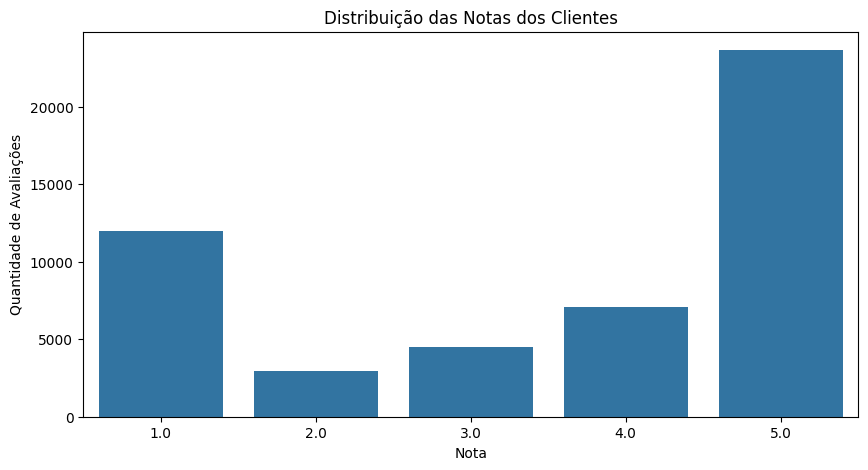

In [354]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_completo,
    x='review_score'
)

plt.title('Distribuição das Notas dos Clientes')
plt.xlabel('Nota')
plt.ylabel('Quantidade de Avaliações')
plt.show()

- A maioria das avaliações do banco são nota 5

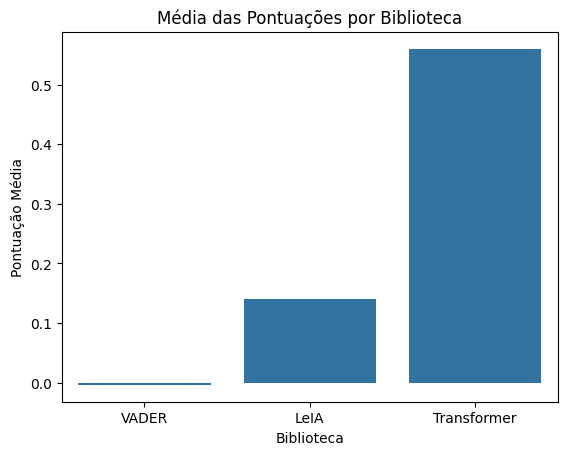

In [355]:
medias = pd.DataFrame({
    'Biblioteca': ['VADER', 'LeIA', 'Transformer'],
    'Pontuação Média': [
        df_completo['pontuacao_vader'].mean(),
        df_completo['pontuacao_leia'].mean(),
        df_completo['pontuacao_transformer'].mean()
    ]
})

sns.barplot(
    data=medias,
    x='Biblioteca',
    y='Pontuação Média'
)

plt.title('Média das Pontuações por Biblioteca')
plt.show()

In [356]:
correlacoes = pd.DataFrame({
    'Biblioteca': ['VADER','LeIA','Transformer'],
    'Correlação': [
        df_completo['review_score'].corr(df_completo['pontuacao_vader']),
        df_completo['review_score'].corr(df_completo['pontuacao_leia']),
        df_completo['review_score'].corr(df_completo['pontuacao_transformer'])
    ]
})

correlacoes

,Biblioteca,Correlação
0,VADER,0.141376
1,LeIA,0.592534
2,Transformer,-0.193034


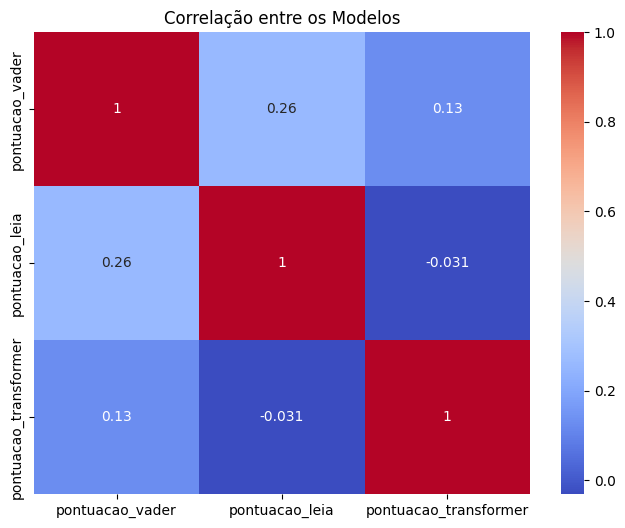

In [357]:
corr = df_completo[
    [
        'pontuacao_vader',
        'pontuacao_leia',
        'pontuacao_transformer'
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlação entre os Modelos')
plt.show()

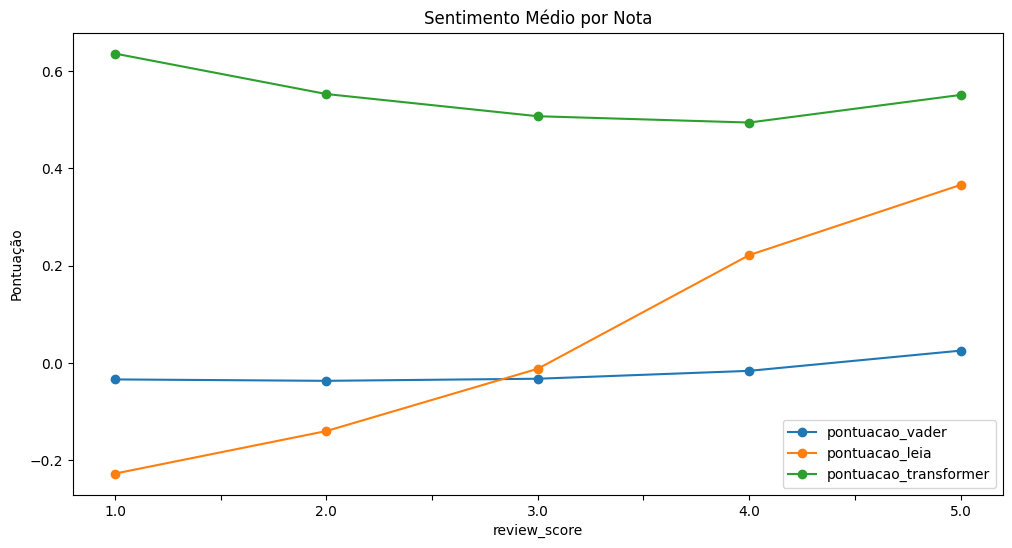

In [358]:
media_por_nota = (
    df_completo
    .groupby('review_score')
    [
        [
            'pontuacao_vader',
            'pontuacao_leia',
            'pontuacao_transformer'
        ]
    ]
    .mean()
)

media_por_nota.plot(
    marker='o',
    figsize=(12,6)
)

plt.title('Sentimento Médio por Nota')
plt.ylabel('Pontuação')
plt.show()

In [360]:
incoerentes = df_completo[
    (df_completo['review_score'] == 5)
    &
    (df_completo['pontuacao_transformer'] < 0.3)
]

incoerentes[
    [
        'review_score',
        'review_comment_message'
    ]
].head(20)

,review_score,review_comment_message
134,5.0,recebi antes do prazo
135,5.0,recebi antes do prazo
226,5.0,otima
289,5.0,entrega antes do prazo
419,5.0,produto chegou no prazo e correto
420,5.0,produto chegou no prazo e correto
545,5.0,mercadoria entregue antes do prazo
582,5.0,um ótimo produto
589,5.0,entrega antes do prazo
659,5.0,chegou antesdo programado


In [361]:
incoerentes2 = df_completo[
    (df_completo['review_score'] == 1)
    &
    (df_completo['pontuacao_transformer'] > 0.7)
]

In [362]:
pd.DataFrame({
    'Tipo': [
        'Nota alta + comentário negativo',
        'Nota baixa + comentário positivo'
    ],
    'Quantidade': [
        len(incoerentes),
        len(incoerentes2)
    ]
})

,Tipo,Quantidade
0,Nota alta + comentário negativo,1867
1,Nota baixa + comentário positivo,4956


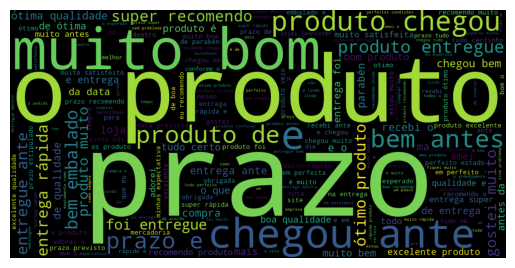

In [363]:
texto = ' '.join(
    df_completo[
        df_completo['review_score'] == 5
    ]['review_comment_message']
)

wordcloud = WordCloud(
    width=1000,
    height=500
).generate(texto)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

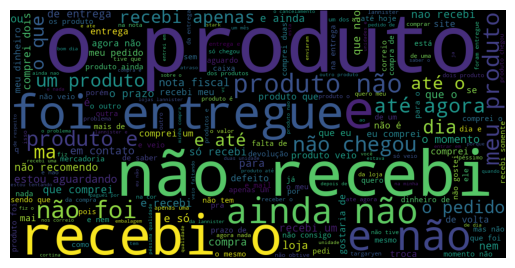

In [364]:
texto = ' '.join(
    df_completo[
        df_completo['review_score'] == 1
    ]['review_comment_message']
)

wordcloud = WordCloud(
    width=1000,
    height=500
).generate(texto)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [365]:
texto = ' '.join(
    df_completo[
        df_completo['review_score'] == 5
    ]['review_comment_message']
)

palavras = texto.split()

top = Counter(palavras).most_common(15)

pd.DataFrame(
    top,
    columns=['Palavra','Frequência']
)

,Palavra,Frequência
0,produto,7818
1,e,7107
2,do,6860
3,o,6090
4,muito,5905
5,antes,5015
6,a,4383
7,de,4352
8,prazo,3673
9,entrega,3626


Text(0, 0.5, 'Palavras')

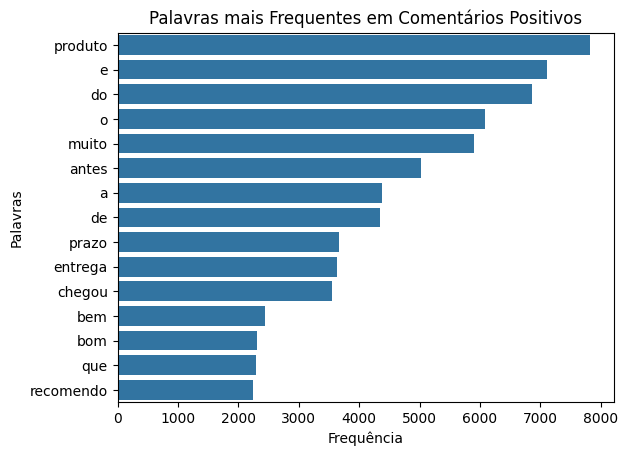

In [366]:
sns.barplot(
    x=[x[1] for x in top],
    y=[x[0] for x in top]
)

plt.title('Palavras mais Frequentes em Comentários Positivos')
plt.xlabel('Frequência')
plt.ylabel('Palavras')

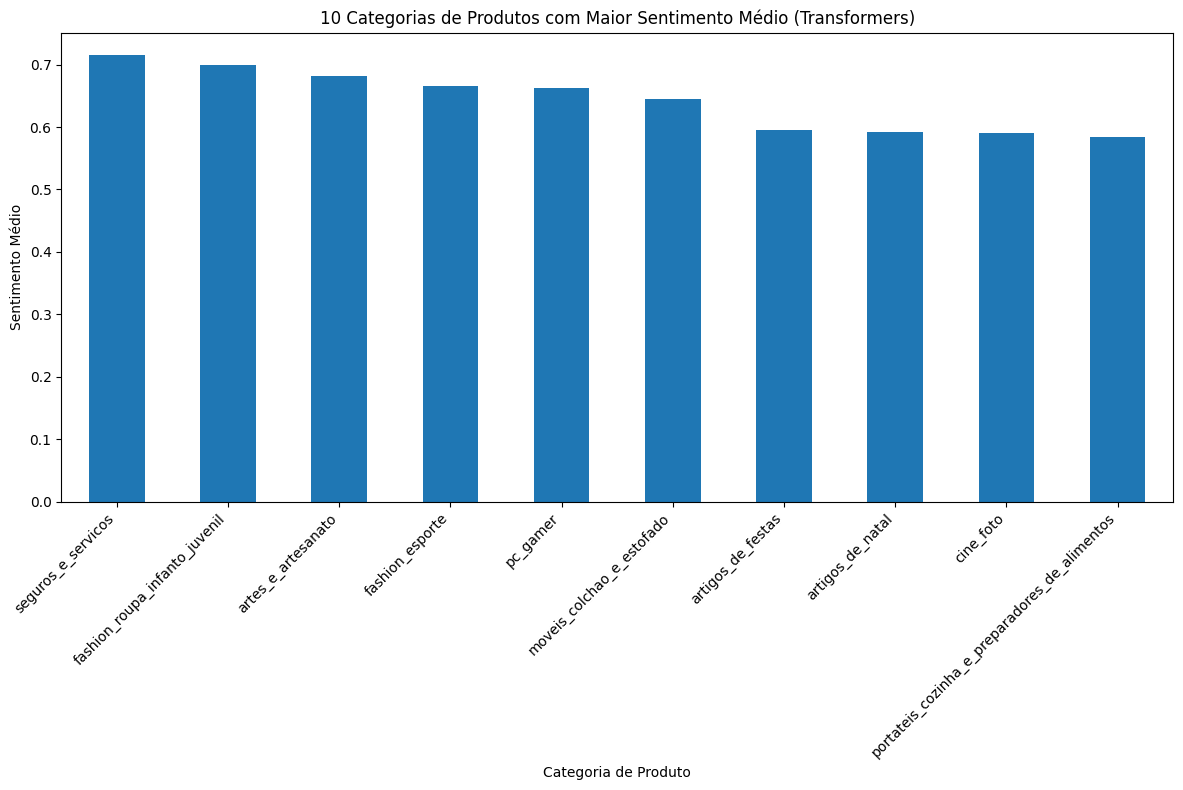

In [367]:
categoria = (
    df_completo
    .groupby('product_category_name')
    ['pontuacao_transformer']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

categoria.plot(
    kind='bar',
    figsize=(12,8)
)

plt.title('10 Categorias de Produtos com Maior Sentimento Médio (Transformers)')
plt.xlabel('Categoria de Produto')
plt.ylabel('Sentimento Médio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [368]:
df_completo['dias_atraso'] = (
    df_completo['order_delivered_customer_date']
    -
    df_completo['order_estimated_delivery_date']
).dt.days

In [369]:
atraso_sentimento = (
    df_completo
    .groupby('dias_atraso')
    [
        [
            'pontuacao_vader',
            'pontuacao_leia',
            'pontuacao_transformer'
        ]
    ]
    .mean()
    .reset_index()
)

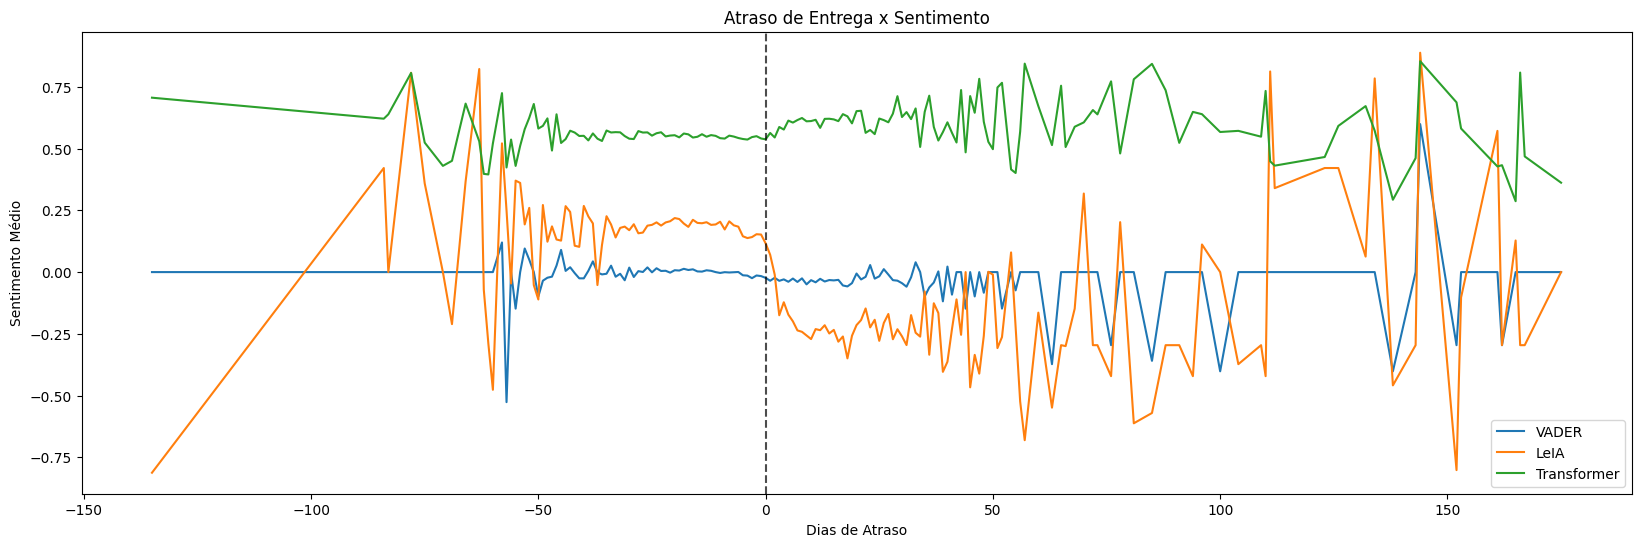

In [370]:
plt.figure(figsize=(20,6))

plt.plot(
    atraso_sentimento['dias_atraso'],
    atraso_sentimento['pontuacao_vader'],
    label='VADER'
)

plt.plot(
    atraso_sentimento['dias_atraso'],
    atraso_sentimento['pontuacao_leia'],
    label='LeIA'
)

plt.plot(
    atraso_sentimento['dias_atraso'],
    atraso_sentimento['pontuacao_transformer'],
    label='Transformer'
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--',
    alpha=0.7
)

plt.title('Atraso de Entrega x Sentimento')
plt.xlabel('Dias de Atraso')
plt.ylabel('Sentimento Médio')
plt.legend()

plt.show()

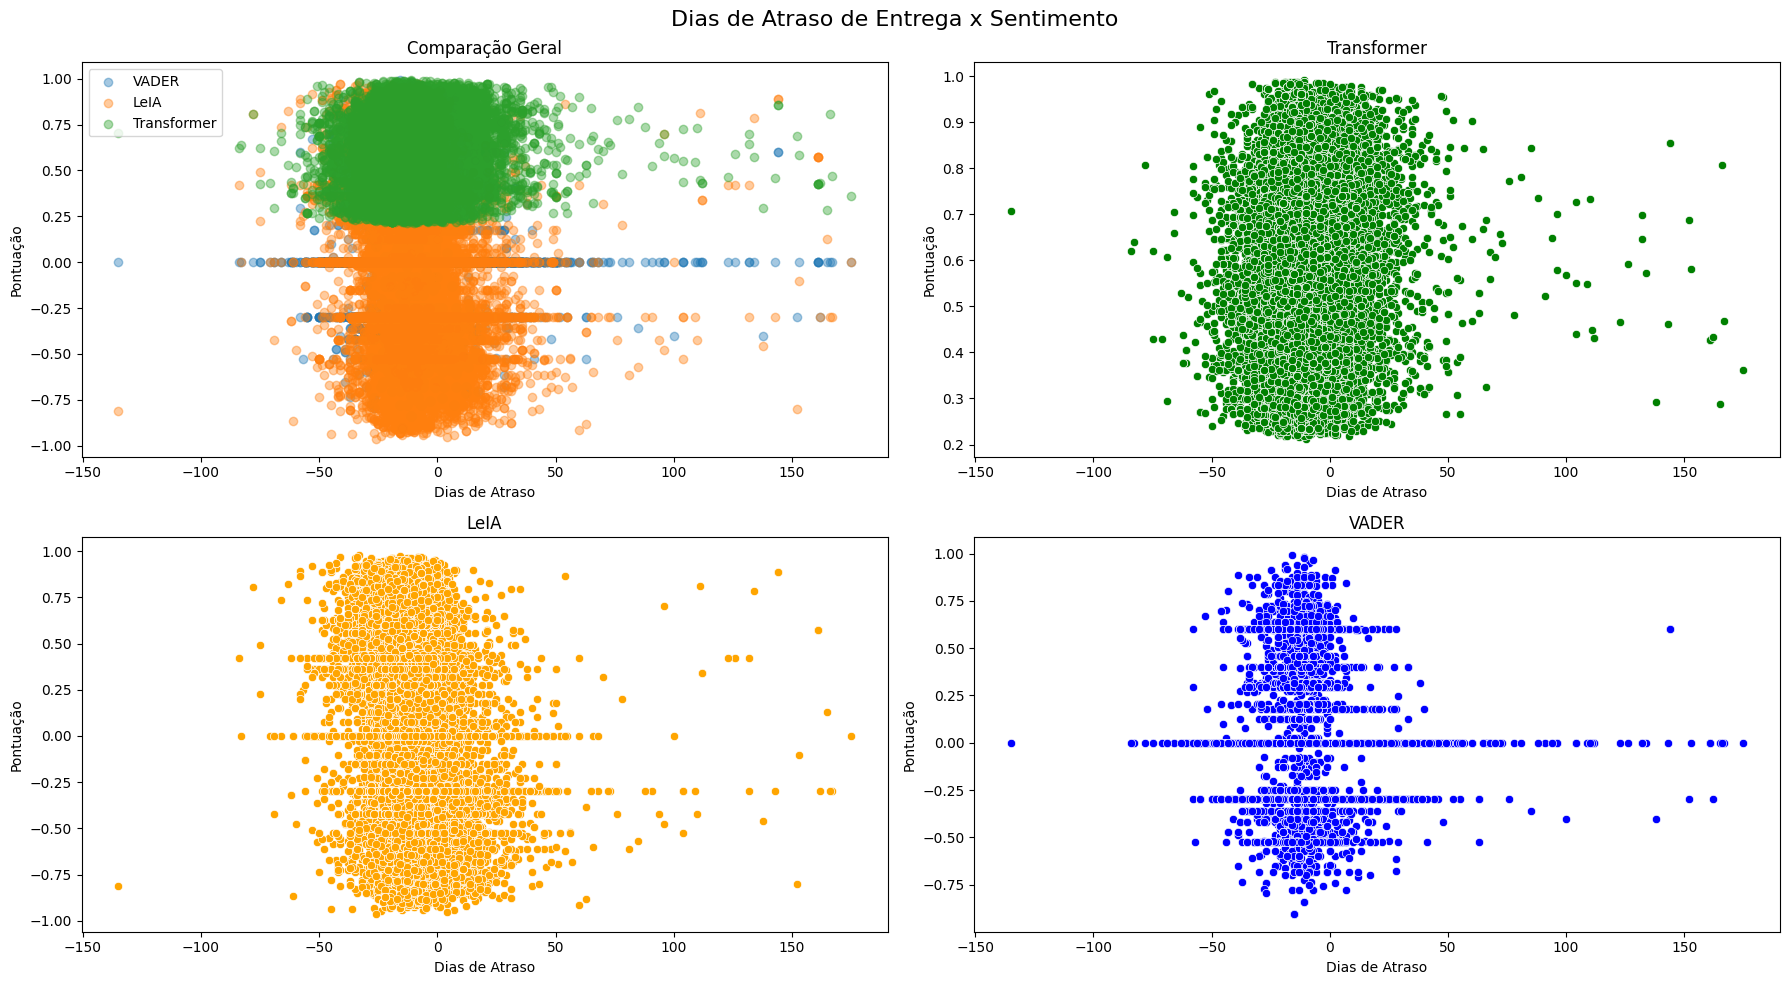

In [372]:
plt.figure(figsize=(18,10))
plt.suptitle('Dias de Atraso de Entrega x Sentimento', fontsize=16)

plt.subplot(2,2,1)

plt.scatter(
    df_completo['dias_atraso'],
    df_completo['pontuacao_vader'],
    alpha=0.4,
    label='VADER'
)

plt.scatter(
    df_completo['dias_atraso'],
    df_completo['pontuacao_leia'],
    alpha=0.4,
    label='LeIA'
)

plt.scatter(
    df_completo['dias_atraso'],
    df_completo['pontuacao_transformer'],
    alpha=0.4,
    label='Transformer'
)

plt.title('Comparação Geral')
plt.xlabel('Dias de Atraso')
plt.ylabel('Pontuação')
plt.legend()


plt.subplot(2,2,2)

sns.scatterplot(
    data=df_completo,
    x='dias_atraso',
    y='pontuacao_transformer',
    color='green'
)

plt.title('Transformer')
plt.xlabel('Dias de Atraso')
plt.ylabel('Pontuação')


plt.subplot(2,2,3)

sns.scatterplot(
    data=df_completo,
    x='dias_atraso',
    y='pontuacao_leia',
    color='orange'
)

plt.title('LeIA')
plt.xlabel('Dias de Atraso')
plt.ylabel('Pontuação')


plt.subplot(2,2,4)

sns.scatterplot(
    data=df_completo,
    x='dias_atraso',
    y='pontuacao_vader',
    color='blue'
)

plt.title('VADER')
plt.xlabel('Dias de Atraso')
plt.ylabel('Pontuação')


plt.tight_layout()
plt.show()

In [373]:
df_completo['faixa_atraso'] = pd.cut(
    df_completo['dias_atraso'],
    bins=[-1000, -5, 0, 5, 15, 1000],
    labels=[
        'Muito Adiantado',
        'No Prazo',
        'Até 5 dias',
        '5-15 dias',
        'Mais de 15 dias'
    ]
)

In [374]:
resultado = (
    df_completo
    .groupby('faixa_atraso')
    [
        [
            'pontuacao_vader',
            'pontuacao_leia',
            'pontuacao_transformer'
        ]
    ]
    .mean()
)

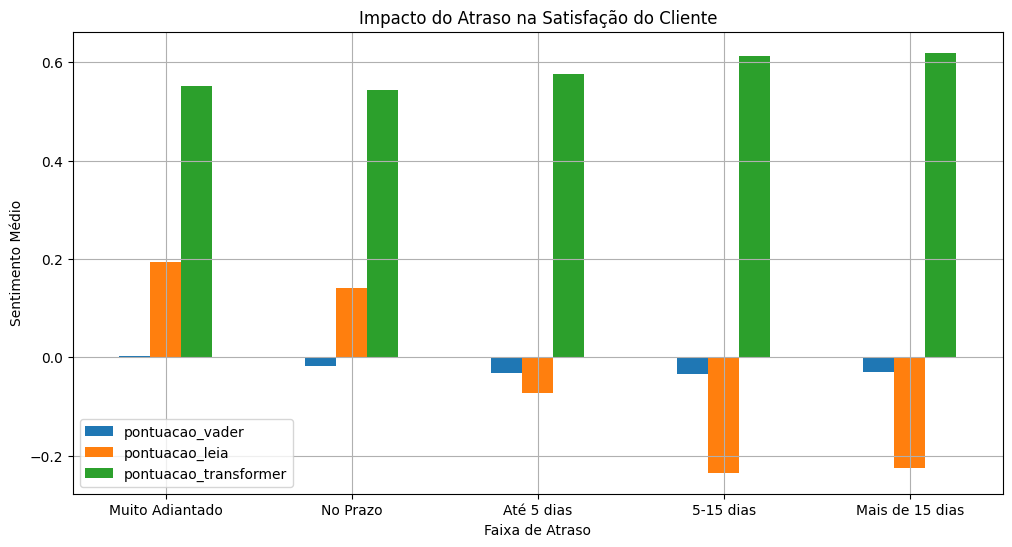

In [375]:
resultado.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Impacto do Atraso na Satisfação do Cliente')
plt.xlabel('Faixa de Atraso')
plt.ylabel('Sentimento Médio')
plt.grid(True)
plt.xticks(rotation=0)

plt.show()

In [376]:
mapa_transformer = {
    '1 star': 'Muito Negativo',
    '2 stars': 'Negativo',
    '3 stars': 'Neutro',
    '4 stars': 'Positivo',
    '5 stars': 'Muito Positivo'
}

df_completo['classificacao_transformer'] = (
    df_completo['classificacao_transformer']
    .map(mapa_transformer)
)

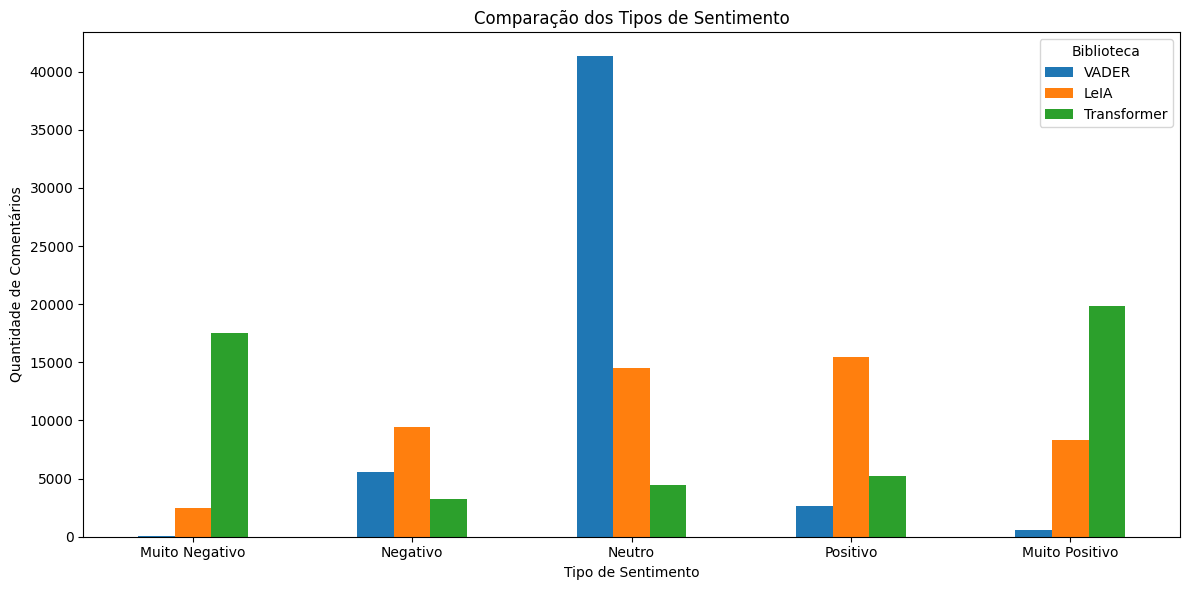

In [377]:
ordem = [
    'Muito Negativo',
    'Negativo',
    'Neutro',
    'Positivo',
    'Muito Positivo'
]

comparacao = pd.DataFrame({
    'VADER': df_completo['classificacao_vader'].value_counts(),
    'LeIA': df_completo['classificacao_leia'].value_counts(),
    'Transformer': df_completo['classificacao_transformer'].value_counts()
}).fillna(0)

comparacao = comparacao.reindex(ordem)

comparacao.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Comparação dos Tipos de Sentimento')
plt.xlabel('Tipo de Sentimento')
plt.ylabel('Quantidade de Comentários')
plt.xticks(rotation=0)
plt.legend(title='Biblioteca')

plt.tight_layout()
plt.show()

In [378]:
df_completo['pontuacao_vader'].mean()

np.float64(-0.0038486119408929756)

In [379]:
df_completo.sort_values(
    'pontuacao_vader',
    ascending=False
)[['review_comment_message','pontuacao_vader']]

,review_comment_message,pontuacao_vader
30400,amo comprar nessa conceituada empresa...spr re...,0.9909
26550,recebi dia 10-10 .veio tudo perfeito! amei o p...,0.9792
40351,😁😁😁😁😁🤗🤗🤗🤗🏇👏👏👏👏👏👏,0.9756
62098,amo comprar nas lojas lannister. parabéns esto...,0.9660
149,muito bom entregou até antes do dia 😆😆😆😆😆😆😆😆,0.9517
...,...,...
84395,"infelizmente não recebi o produto, comprei com...",-0.8885
71909,comprei 3 whey protein e 1 hemo rage no mesmo ...,-0.9039
71911,comprei 3 whey protein e 1 hemo rage no mesmo ...,-0.9039
71912,comprei 3 whey protein e 1 hemo rage no mesmo ...,-0.9039


In [381]:
df_completo.sort_values(
    'pontuacao_vader'
)[['review_comment_message','pontuacao_vader']]

,review_comment_message,pontuacao_vader
71912,comprei 3 whey protein e 1 hemo rage no mesmo ...,-0.9039
71909,comprei 3 whey protein e 1 hemo rage no mesmo ...,-0.9039
71911,comprei 3 whey protein e 1 hemo rage no mesmo ...,-0.9039
71910,comprei 3 whey protein e 1 hemo rage no mesmo ...,-0.9039
84395,"infelizmente não recebi o produto, comprei com...",-0.8885
...,...,...
149,muito bom entregou até antes do dia 😆😆😆😆😆😆😆😆,0.9517
62098,amo comprar nas lojas lannister. parabéns esto...,0.9660
40351,😁😁😁😁😁🤗🤗🤗🤗🏇👏👏👏👏👏👏,0.9756
26550,recebi dia 10-10 .veio tudo perfeito! amei o p...,0.9792


In [382]:
df_completo.groupby(
    'review_score'
)['pontuacao_vader'].mean()

review_score
1.0   -0.034196
2.0   -0.037094
3.0   -0.032786
4.0   -0.016563
5.0    0.025011
Name: pontuacao_vader, dtype: float64